# S6 · Do the classes read odorants from water?

Class I is often called the aquatic class. This asks whether the odorants it reads come from
organisms that live in water. Habitat is read off each source organism's NCBI lineage by
`Chemicals/c12_aquatic_sources.py`; bacteria and fungi are left unassigned, and mammals and
birds are dropped as host records. Only the odorants COCONUT has a source for count, which
leaves small exclusive sets, so only a large difference would show. None does.

## Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")   # library deprecation notices only
%config InlineBackend.figure_format = 'png'

REPO = Path("../../../..").resolve()
sys.path.append(str(REPO / "Downstream_Analysis/scripts"))
sys.path.append(str(REPO / "scripts"))
import activation_code as ac
import activation_figures as af
from plotting_functions import FIGSIZE, custom_plots

plt.rcParams.update(custom_plots())

PROBABILITIES = REPO / "Downstream_Analysis/predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv"
M2OR_PAIRS = REPO / "Model_Inputs/Data_Preparation/processed/m2or_pairs_model.csv"
ODOURS = REPO / "Chemicals/processed_data/m2or_inchi_odors_smiles.csv"
PATHWAYS = REPO / "Chemicals/processed_data/ligand_pathways.csv"
FASTA = REPO / "Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa"
CLASSES = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_OR_classes.csv"
TREE = REPO / "Phylogenetic_Analysis/data/HumanTree/human433_MFP_reorder.tree"

FIGURES = Path("Figures")
TABLES = Path("Tables")
MAIN_TABLES = Path("../Tables")     # written by ../figure2_activation_code.ipynb
FIGURES.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)
NAME = "hybrid_density"

AQUATIC_SOURCES = REPO / "Chemicals/results/aquatic_sources_panel.csv"
if not AQUATIC_SOURCES.exists():
    AQUATIC_SOURCES = REPO / "Chemicals/results/aquatic_sources.csv"
PANEL_JOIN = REPO / "Chemicals/results/panel_universe_join.csv"

In [2]:
data = ac.load_activation_data(PROBABILITIES, M2OR_PAIRS, FASTA)
smiles_by_odorant, tags_by_odorant = ac.odour_tags(M2OR_PAIRS, ODOURS, data.odorant_ids)
class_of = ac.receptor_classes(CLASSES)
print(f"density {data.fill.density:.4%}   cut {data.fill.cut:.4f} (an output of the fill)")

density 2.7453%   cut 0.8917 (an output of the fill)


The first row is over every odorant of the set; the rest only over those COCONUT knows a
source for. An odorant COCONUT has never seen counts as unknown, not as zero aquatic sources.

In [3]:
AQUATIC_BLOCKS = [
    ("found in nature at all", [
        ("in_coconut", "recorded as a natural product", "mean", "%.0f%%")]),
    ("aquatic origin — among those with a recorded source", [
        ("any_aquatic", "has an aquatic source organism", "mean", "%.0f%%"),
        ("share_aquatic", "aquatic share of its sources", "mean", "%.3f"),
        ("marine_db", "in a marine natural-product database", "mean", "%.0f%%"),
        ("n_aquatic", "aquatic source organisms", "mean", "%.2f"),
        ("n_organisms", "source organisms recorded", "median", "%.0f")]),
]

groups, rate, rate_I, rate_II, in_I, in_II = ac.class_partition(data.hybrid, data.receptor_ids, class_of)
join = pd.read_csv(PANEL_JOIN)[["smiles_id", "inchikey"]]
sources = pd.read_csv(AQUATIC_SOURCES)
origin = (pd.DataFrame({"sml": data.odorant_ids, "in_I": in_I, "in_II": in_II})
          .query("in_I or in_II")
          .merge(join, left_on="sml", right_on="smiles_id", how="left")
          .merge(sources, on="inchikey", how="left"))
origin["in_coconut"] = origin.n_organisms.notna().astype(float)
for column in ["any_aquatic", "marine_db"]:
    origin[column] = origin[column].map({True: 1.0, False: 0.0})
print(f"odorants {len(origin)}   in COCONUT {int(origin.in_coconut.sum())}   with a placed organism "
      f"{int(origin.share_aquatic.notna().sum())}   with an aquatic source {int(np.nansum(origin.any_aquatic))}")

odorants 499   in COCONUT 281   with a placed organism 263   with an aquatic source 130


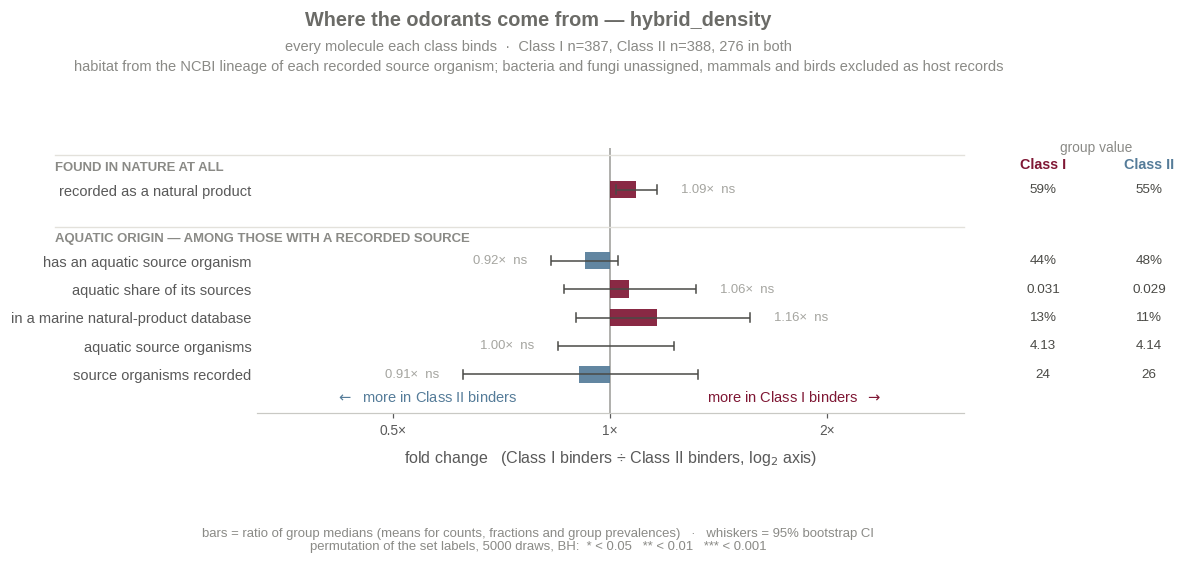

  aquatic_origin_hybrid_density              


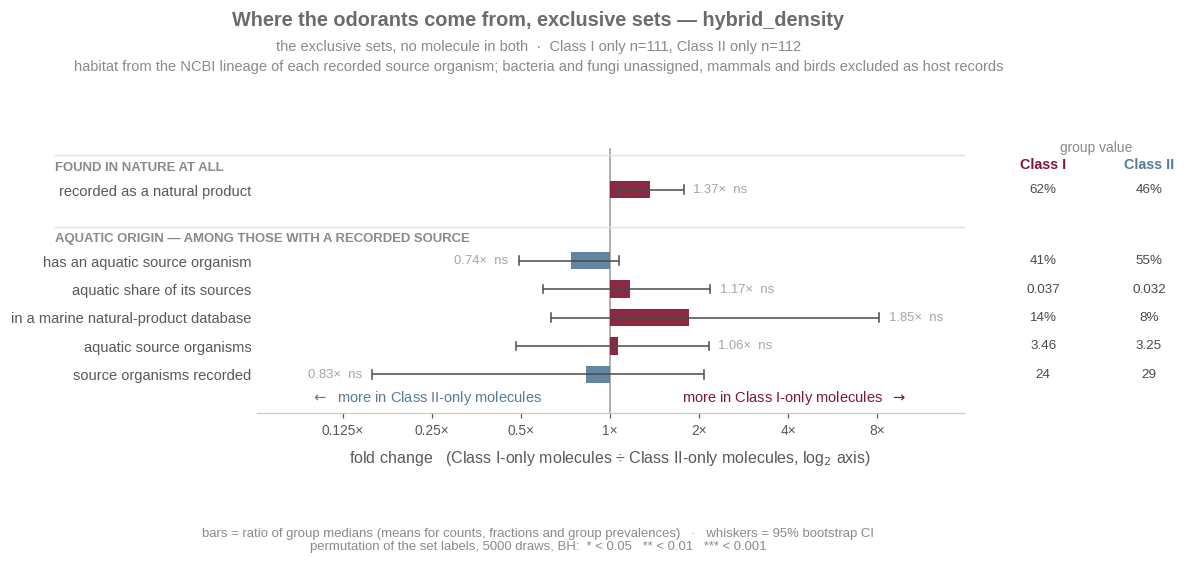

  aquatic_origin_hybrid_density_exclusive    


,property,fold_change_I_over_II,ci_lo,ci_hi,class_I,class_II,summary,perm_p,perm_q,cliffs_delta
0,in_coconut,1.365130,1.074055,1.771918,0.621622,0.455357,mean,0.013197,0.079184,0.166264
1,any_aquatic,0.739130,0.490166,1.074639,0.405797,0.549020,mean,0.127175,0.381524,-0.143223
2,share_aquatic,1.167776,0.593925,2.175074,0.037376,0.032006,mean,0.680864,0.879424,-0.051613
3,marine_db,1.847826,0.633125,8.093978,0.144928,0.078431,mean,0.254549,0.509098,0.066496
4,n_aquatic,1.064170,0.478959,2.150776,3.463768,3.254902,mean,0.879424,0.879424,-0.132708
5,n_organisms,0.827586,0.156857,2.078947,24.000000,29.000000,median,0.857029,0.879424,-0.124751


In [4]:
full_I, full_II = origin.in_I.values, origin.in_II.values
habitat_note = ("habitat from the NCBI lineage of each recorded source organism; "
                "bacteria and fungi unassigned, mammals and birds excluded as host records")
af.fold_change_figure(
    origin, full_I, full_II, f"Where the odorants come from — {NAME}",
    f"every molecule each class binds  ·  Class I n={full_I.sum()}, Class II n={full_II.sum()}, "
    f"{(full_I & full_II).sum()} in both\n" + habitat_note,
    "Class I binders", "Class II binders", FIGURES / f"aquatic_origin_{NAME}.svg",
    TABLES / f"aquatic_origin_{NAME}.csv", show=True, blocks=AQUATIC_BLOCKS)
af.fold_change_figure(
    origin, full_I & ~full_II, full_II & ~full_I, f"Where the odorants come from, exclusive sets — {NAME}",
    f"the exclusive sets, no molecule in both  ·  Class I only n={(full_I & ~full_II).sum()}, "
    f"Class II only n={(full_II & ~full_I).sum()}\n" + habitat_note,
    "Class I-only molecules", "Class II-only molecules", FIGURES / f"aquatic_origin_{NAME}_exclusive.svg",
    TABLES / f"aquatic_origin_{NAME}_exclusive.csv", show=True, blocks=AQUATIC_BLOCKS)